In [134]:
%matplotlib inline
import math
import torch
from torch import nn
from torch.nn import functional as F
from d2l import torch as d2l

In [136]:
X, W_xh = torch.normal(0, 1, (3, 1)), torch.normal(0, 1, (1, 4))
H, W_hh = torch.normal(0, 1, (3, 4)), torch.normal(0, 1, (4, 4))
torch.matmul(X, W_xh) + torch.matmul(H, W_hh)

tensor([[ 0.9388, -0.6208,  0.7355, -2.6571],
        [-1.3216,  3.4904,  2.0575,  3.0889],
        [ 3.0705, -3.8410, -4.2020, -2.7816]])

In [138]:
torch.matmul(torch.cat((X, H), 1), torch.cat((W_xh, W_hh), 0))

tensor([[ 0.9388, -0.6208,  0.7355, -2.6571],
        [-1.3216,  3.4904,  2.0575,  3.0889],
        [ 3.0705, -3.8410, -4.2020, -2.7816]])

In [140]:
batch_size, num_steps = 32, 35
train_iter, vocab = d2l.load_data_time_machine(batch_size, num_steps)

In [142]:
F.one_hot(torch.tensor([0, 2]), len(vocab))

tensor([[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0],
        [0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0]])

In [144]:
X = torch.arange(10).reshape((2, 5))
F.one_hot(X.T, 28).shape

torch.Size([5, 2, 28])

In [146]:
def get_params(vocab_size, num_hiddens, device):
    num_inputs = num_outputs = vocab_size

    def normal(shape):
        return torch.randn(size=shape, device=device) * 0.01

    W_xh = normal((num_inputs, num_hiddens))
    W_hh = normal((num_hiddens, num_hiddens))
    b_h = torch.zeros(num_hiddens, device=device)

    W_hq = normal((num_hiddens, num_outputs))
    b_q = torch.zeros(num_outputs, device=device)

    params = [W_xh, W_hh, b_h, W_hq, b_q]
    for param in params:
        param.requires_grad_(True)
    return params


In [148]:
def init_rnn_state(batch_size, num_hiddens, device):
    return (torch.zeros((batch_size, num_hiddens), device=device), )

In [150]:
def rnn(inputs, state, params):
    W_xh, W_hh, b_h, W_hq, b_q = params
    H, = state
    outputs = []
    for X in inputs:
        H = torch.tanh(torch.mm(X, W_xh) + torch.mm(H, W_hh) + b_h)
        Y = torch.mm(H, W_hq) + b_q
        outputs.append(Y)
    return torch.cat(outputs, dim=0), (H,)

In [152]:
class RNNModelScratch:  # @save
    def __init__(self, vocab_size, num_hiddens, device,
                 get_params, init_state, forward_fn):
        self.vocab_size, self.num_hiddens = vocab_size, num_hiddens
        self.params = get_params(vocab_size, num_hiddens, device)
        self.init_state, self.forward_fn = init_state, forward_fn

    def __call__(self, X, state):
        X = F.one_hot(X.T, self.vocab_size).type(torch.float32)
        return self.forward_fn(X, state, self.params)

    def begin_state(self, batch_size, device):
        return self.init_state(batch_size, self.num_hiddens, device)


In [154]:
num_hiddens = 512
net = RNNModelScratch(len(vocab), num_hiddens, d2l.try_gpu(), get_params,
                      init_rnn_state, rnn)
state = net.begin_state(X.shape[0], d2l.try_gpu())
Y, new_state = net(X.to(d2l.try_gpu()), state)
Y.shape, len(new_state), new_state[0].shape

(torch.Size([10, 28]), 1, torch.Size([2, 512]))

In [156]:
def predict_ch8(prefix, num_preds, net, vocab, device):  # @save
    state = net.begin_state(batch_size=1, device=device)
    outputs = [vocab[prefix[0]]]
    get_input = lambda: torch.tensor([outputs[-1]], device=device).reshape((1, 1))
    for y in prefix[1:]:
        _, state = net(get_input(), state)
        outputs.append(vocab[y])
    for _ in range(num_preds):
        y, state = net(get_input(), state)
        outputs.append(int(y.argmax(dim=1).reshape(1)))
    return ''.join([vocab.idx_to_token[i] for i in outputs])

In [158]:
predict_ch8('time traveller ', 10, net, vocab, d2l.try_gpu())

'time traveller hwliktiaia'

In [178]:
#it has bug

# def grad_clipping(net, theta):
#     if isinstance(net, nn.Module):
#         params = [p for p in net.parameters() if p.requires_grad]
#     else:
#         params = net.params
#     norm = torch.sqrt(sum(torch.sum((p.grad ** 2)) for p in params))
#     if norm > theta:
#         for param in params:
#             param.grad[:] *= theta / norma / norm

In [162]:
def train_epoch_ch8(net, train_iter, loss, updater, device, use_random_iter):  # @save
    state, timer = None, d2l.Timer()
    metric = d2l.Accumulator(2)  
    for X, Y in train_iter:
        if state is None or use_random_iter:
            state = net.begin_state(batch_size=X.shape[0], device=device)
        else:
            if isinstance(net, nn.Module) and not isinstance(state, tuple):
                state.detach_()
            else:
                for s in state:
                    s.detach_()
        y = Y.T.reshape(-1)
        X, y = X.to(device), y.to(device)
        y_hat, state = net(X, state)
        l = loss(y_hat, y.long()).mean()
        if isinstance(updater, torch.optim.Optimizer):
            updater.zero_grad()
            l.backward()
            grad_clipping(net, 1)
            updater.step()
        else:
            l.backward()
            grad_clipping(net, 1)
            updater(batch_size=1)
        metric.add(l * y.numel(), y.numel())
    return math.exp(metric[0] / metric[1]), metric[1] / timer.stop()


In [164]:
def train_ch8(net, train_iter, vocab, lr, num_epochs, device, use_random_iter=False):  # @save
    loss = nn.CrossEntropyLoss()
    animator = d2l.Animator(xlabel='epoch', ylabel='perplexity',
                            legend=['train'], xlim=[10, num_epochs])
    if isinstance(net, nn.Module):
        updater = torch.optim.SGD(net.parameters(), lr)
    else:
        updater = lambda batch_size: d2l.sgd(net.params, lr, batch_size)
    predict = lambda prefix: predict_ch8(prefix, 50, net, vocab, device)
    for epoch in range(num_epochs):
        ppl, speed = train_epoch_ch8(net, train_iter, loss, updater, device, use_random_iter)
        if (epoch + 1) % 10 == 0:
            print(predict('time traveller'))
        animator.add(epoch + 1, [ppl])
        print(f'Perplexity {ppl:.1f}, {speed:.1f} Words/second {str(device)}')
        print(predict('time traveller'))
        print(predict('traveller'))

In [170]:
print(grad_clipping.__code__.co_code)
import inspect
print(inspect.getsource(grad_clipping))

b't\x00|\x00t\x01j\x02\x83\x02r d\x01d\x02\x84\x00|\x00\xa0\x03\xa1\x00D\x00\x83\x01}\x02n\x06|\x00j\x04}\x02t\x05\xa0\x06t\x07d\x03d\x04\x84\x00|\x02D\x00\x83\x01\x83\x01\xa1\x01}\x03|\x03|\x01k\x04rn|\x02D\x00]"}\x04|\x04j\x08d\x00d\x00\x85\x02\x05\x00\x19\x00|\x01t\t\x1b\x00|\x03\x1b\x009\x00\x03\x00<\x00qJd\x00S\x00'
def grad_clipping(net, theta):
    if isinstance(net, nn.Module):
        params = [p for p in net.parameters() if p.requires_grad]
    else:
        params = net.params
    norm = torch.sqrt(sum(torch.sum((p.grad ** 2)) for p in params))
    if norm > theta:
        for param in params:
            param.grad[:] *= theta / norma / norm



In [172]:
def grad_clipping(net, theta):
    if isinstance(net, nn.Module):
        params = [p for p in net.parameters() if p.requires_grad]
    else:
        params = net.params
    with torch.no_grad():
        norm = torch.sqrt(sum(torch.sum(p.grad**2) for p in params))
        if norm > theta and norm > 0:
            scale = theta / norm
            for p in params:
                p.grad.mul_(scale)

In [174]:
import inspect
print(inspect.getsource(grad_clipping))

def grad_clipping(net, theta):
    if isinstance(net, nn.Module):
        params = [p for p in net.parameters() if p.requires_grad]
    else:
        params = net.params
    with torch.no_grad():
        norm = torch.sqrt(sum(torch.sum(p.grad**2) for p in params))
        if norm > theta and norm > 0:
            scale = theta / norm
            for p in params:
                p.grad.mul_(scale)



Perplexity 1.0, 51440.5 Words/second cuda:0
time travelleryou can show black is white by argument said filby
travelleryou can show black is white by argument said filby


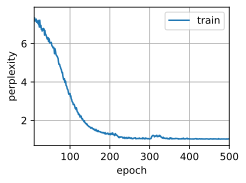

In [176]:
num_epochs, lr = 500, 1
train_ch8(net, train_iter, vocab, lr, num_epochs, d2l.try_gpu())

Perplexity 1.4, 126143.6 Words/second cuda:0
time travellerit s against reason said filbywhat of it ursatwy a
travellerit s against reason said filbywhat of it ursatwy a


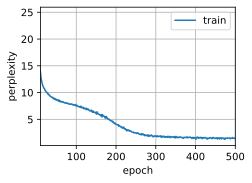

In [180]:
net = RNNModelScratch(len(vocab), num_hiddens, d2l.try_gpu(), get_params,
                      init_rnn_state, rnn)
train_ch8(net, train_iter, vocab, lr, num_epochs, d2l.try_gpu(),
          use_random_iter=True)